In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

uploaded = files.upload()

Saving Iris.xlsx to Iris.xlsx


Original Dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


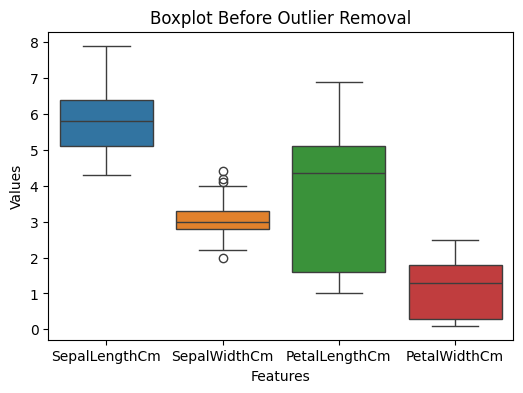


Dataset after Removing Outliers:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Original Shape: (150, 6)
Shape After Removing Outliers: (146, 6)


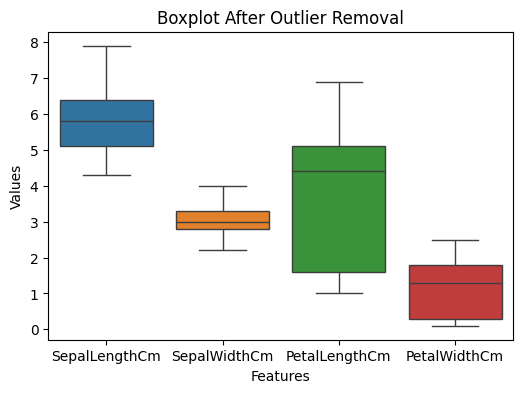

In [2]:

df = pd.read_excel('Iris.xlsx')


print("Original Dataset:")
print(df.head())


plt.figure(figsize=(6,4))
sns.boxplot(data=df[['SepalLengthCm',
                     'SepalWidthCm',
                     'PetalLengthCm',
                     'PetalWidthCm']])

plt.title('Boxplot Before Outlier Removal')
plt.xlabel('Features')
plt.ylabel('Values')
plt.show()


numeric_cols = [
    'SepalLengthCm',
    'SepalWidthCm',
    'PetalLengthCm',
    'PetalWidthCm'
]


df_clean = df.copy()


for col in numeric_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower_limit) &
        (df_clean[col] <= upper_limit)
    ]


print("\nDataset after Removing Outliers:")
print(df_clean.head())

print("\nOriginal Shape:", df.shape)
print("Shape After Removing Outliers:", df_clean.shape)


plt.figure(figsize=(6,4))
sns.boxplot(data=df_clean[['SepalLengthCm',
                           'SepalWidthCm',
                           'PetalLengthCm',
                           'PetalWidthCm']])

plt.title('Boxplot After Outlier Removal')
plt.xlabel('Features')
plt.ylabel('Values')
plt.show()